### Setup

In [127]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Importação

In [128]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os
import shutil
import string
import random

## Criação dos valores a serem calculados os anagramas

In [129]:
def gerar_palavra(tamanho):
    return ''.join(random.choices(string.ascii_lowercase, k=tamanho))

qtd_values = [100, 200, 300, 400, 500, 600, 700, 800, 900]
dados = [gerar_palavra(qtd) for qtd in qtd_values]


### Exibindo Amostragem

In [130]:
print(f"Palavras geradas: {dados}")
print(f"Quantidades de dados gerados: {len(dados)}", qtd_values)

Palavras geradas: ['uydvchgckcgibfnccpgbedkptdjlpxwkgadxsbaddlibyesknxuopiwkbuerjimgpeymejujbyivskwjairpajepofhwwxxkpnor', 'mjzmerofxwfojckfanezlymbqiirmawuhizragtdztfduvgxanuyxqqrexgwizffabzbijofvozxqojjkkigyqmfttjingykhcuesolojrxwmucnsmbtwfxwwuiipivgzdxcvvcysrfmdmvekmupzvakkjkhmtxwmidrdjelkgvvsmnayjhzpvqwwkscorradikkwdyz', 'lykcqlkgiqmancxrxkurldvkirgbgyldmvjhifksxarpjcckaqydguofqtashhvndvughzwtyostslnjrlpprowmyufbmwjdxgpwfhlwdpvodpsaezgxoopyqepeftzcxxtlmtvcjslszbmefjuxtbrhvjggtuskbcezmwqqosddaywwalrguktveutixwvtqmlvljffjjotlpbxeyliplszsjqwwbanarajjngchsrvpbwekdwphqxsvqhvcjekezslwjxuzlgndcmuhcwcjrcxlzforwamsntjnleynegi', 'yfkbrtcszowcetvmgriimfirioxzkzomvstmtuasaeatovfodojqitpjfvhybgluojundzohhyyumoqjtondjcnbjfyifhjshrvwjdynhtguvtkhikuafqofavfrdufqnecsiipmfdzbwhcudqmaiabzlrystqcffgoaljtgjqtfkpfjubeuaknnordzcqvxjrnqrdfsbxhzhxhosanwqwdixtqqsfvsyjzlzlukihhotfbplbyadygsshcilgrhjpbtwwqzszalnvegdllgxgzhhtxmsfbplqhbiucipbxzwzzmdmckzyqnlbgsuprvbvpskbhfkeqlqllldhhuhrxcosnpjkoylfucwgaemihanteo

### Salvando amostragem em txt

In [131]:
paths = []

# Caminho base
base_path = 'files/palavras'
shutil.rmtree('files', ignore_errors=True)
os.makedirs(base_path, exist_ok=True)

for palavra in dados:
    path = f'files/palavras/{len(palavra)}_letras.csv'
    paths.append(path)
    with open(path, 'w') as f:
        f.write(f'{palavra}\n')
            
print(f'Arquivos salvos em {os.path.abspath("files")}')

Arquivos salvos em /home/user/Projetos/Trabalho-2---PAA/files


## Recursivo

In [132]:
%%capture anagrama_results_recursive
for path in paths:
    tamanho = path.split('/')[-1].split('.')[0].split('_')[0]
    args_copy = f"FILE_PATH={path} QTD_TEST=25 SHOW_RESULT=0"
    !make -B anagrama_recursivo {args_copy}

In [133]:
anagrama_results_recursive.show()

Tempo:0.000215s Memoria:5.40KB QTD:100
Tempo:0.000505s Memoria:9.50KB QTD:200
Tempo:0.001215s Memoria:15.00KB QTD:300
Tempo:0.002062s Memoria:22.23KB QTD:400
Tempo:0.003081s Memoria:29.46KB QTD:500
Tempo:0.004329s Memoria:36.68KB QTD:600
Tempo:0.005978s Memoria:43.91KB QTD:700
Tempo:0.007422s Memoria:51.14KB QTD:800
Tempo:0.009296s Memoria:58.36KB QTD:900


## Dinamico

In [134]:
%%capture anagrama_results_dinamico
for path in paths:
    tamanho = path.split('/')[-1].split('.')[0].split('_')[0]
    args_copy = f"FILE_PATH={path} QTD_TEST=25 SHOW_RESULT=0"
    !make -B anagrama_dinamico {args_copy}

In [135]:
anagrama_results_dinamico.show()

Tempo:0.000113s Memoria:2.64KB QTD:100
Tempo:0.000205s Memoria:3.04KB QTD:200
Tempo:0.000309s Memoria:3.39KB QTD:300
Tempo:0.000429s Memoria:3.77KB QTD:400
Tempo:0.000553s Memoria:4.17KB QTD:500
Tempo:0.000689s Memoria:4.58KB QTD:600
Tempo:0.000834s Memoria:5.01KB QTD:700
Tempo:0.000944s Memoria:5.44KB QTD:800
Tempo:0.001099s Memoria:5.89KB QTD:900


# Graficos

In [136]:
def formatar_dados(results):
  # Extrai os dados do resultado
  data = []
  lines = results.stdout.split('\n')
  
  for line in lines:
      if line.startswith('Tempo:'):
          parts = line.split()
          tempo = parts[0].split(':')[1][:-1]
          memoria = parts[1].split(':')[1][:-2]
          qtd = parts[2].split(':')[1]
          data.append((tempo, memoria, qtd))
  return pd.DataFrame(data, columns=["Tempo", "Memoria", "Qtd"])


In [137]:
print("\nAnagramas recursivo")
formatado_recusivo = formatar_dados(anagrama_results_recursive)
formatado_recusivo


Anagramas recursivo


,Tempo,Memoria,Qtd
0,0.000215,5.40,100
1,0.000505,9.50,200
2,0.001215,15.00,300
3,0.002062,22.23,400
4,0.003081,29.46,500
5,0.004329,36.68,600
6,0.005978,43.91,700
7,0.007422,51.14,800
8,0.009296,58.36,900


In [138]:
print("\nAnagramas recursivo")
formatado_dinamico = formatar_dados(anagrama_results_dinamico)
formatado_dinamico


Anagramas recursivo


,Tempo,Memoria,Qtd
0,0.000113,2.64,100
1,0.000205,3.04,200
2,0.000309,3.39,300
3,0.000429,3.77,400
4,0.000553,4.17,500
5,0.000689,4.58,600
6,0.000834,5.01,700
7,0.000944,5.44,800
8,0.001099,5.89,900


In [139]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def gerar_graficos(data):
    # Converte os dados de tempo e memória para float
    data["Tempo"] = data["Tempo"].astype(float)
    data["Memoria"] = data["Memoria"].astype(float)
    data["Qtd"] = data["Qtd"].astype(int)

    # Configura os gráficos lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Configura o formatador para evitar notação científica nos eixos
    formatter = ScalarFormatter()
    formatter.set_scientific(False)
    formatter.set_useOffset(False)

    # Gráfico de Tempo
    axes[0].plot(data["Qtd"], data["Tempo"], marker='o', label="Tempo")
    axes[0].set_title("Tempo de Execução")
    axes[0].set_xlabel("Quantidade de Palavras")
    axes[0].set_ylabel("Tempo (s)")
    axes[0].grid(True)
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(formatter)

    # Gráfico de Memória
    axes[1].plot(data["Qtd"], data["Memoria"], marker='o', color='orange', label="Memória")
    axes[1].set_title("Uso de Memória")
    axes[1].set_xlabel("Quantidade de letras")
    axes[1].set_ylabel("Memória (KB)")
    axes[1].grid(True)
    axes[1].legend()
    axes[1].yaxis.set_major_formatter(formatter)

    # Exibe os valores reais nos gráficos formatados
    for i, row in data.iterrows():
        axes[0].text(row["Qtd"], row["Tempo"], f"{row['Tempo']:.6f}", fontsize=9, ha='right')  # Formata para 4 casas decimais
        axes[1].text(row["Qtd"], row["Memoria"], f"{row['Memoria']:.2f}", fontsize=9, ha='right')  # Formata para 2 casas decimais

    plt.tight_layout()
    plt.show()


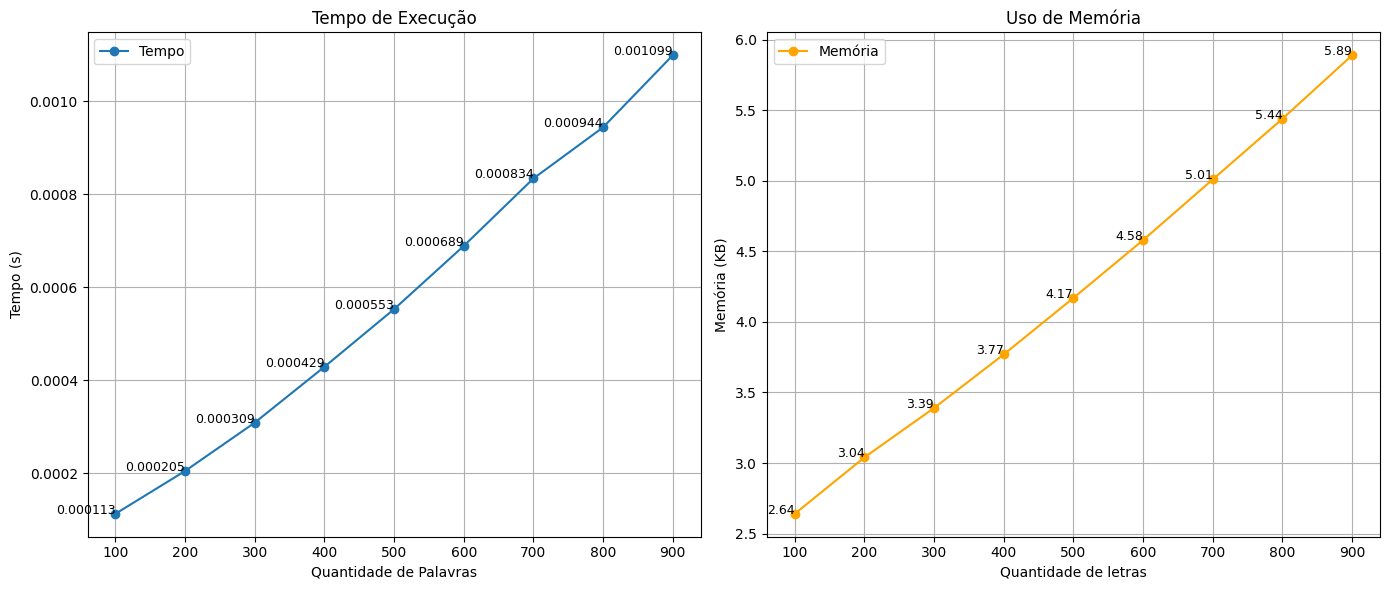

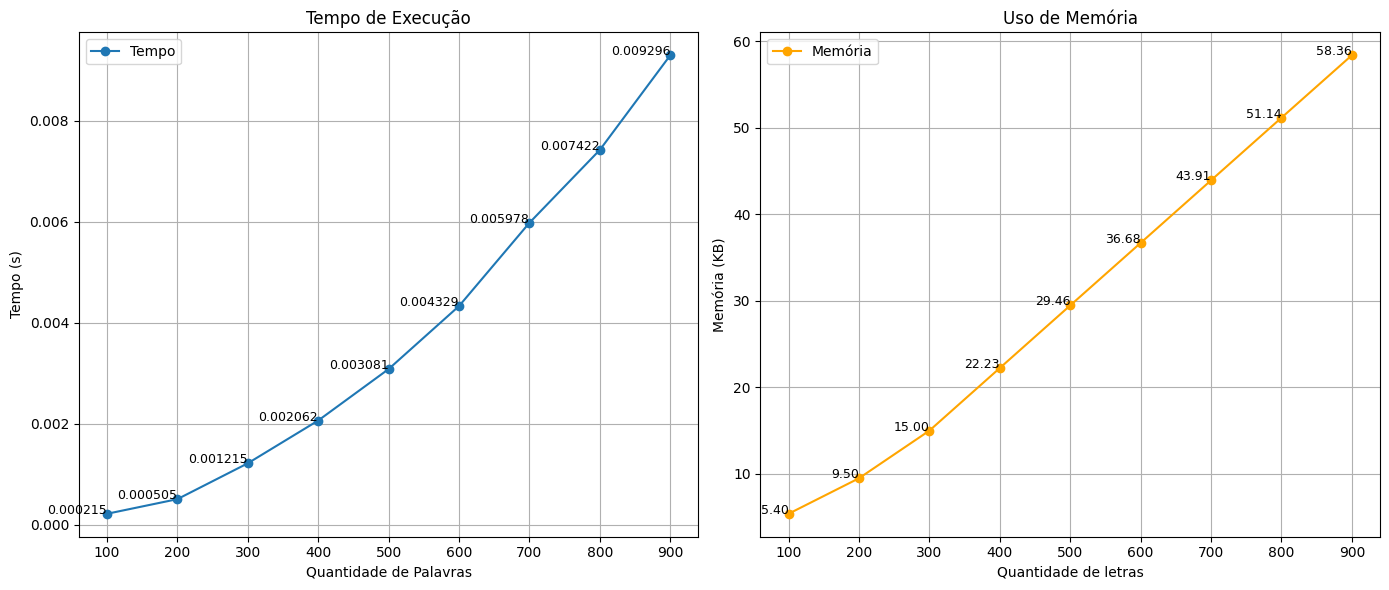

In [140]:
gerar_graficos(formatar_dados(anagrama_results_dinamico))
gerar_graficos(formatar_dados(anagrama_results_recursive))